# Comparativa de 3 Fuentes de Búsqueda Local

| Fuente | Descripción | Columna |
|---|---|---|
| **GPT + WebSearch** | GPT con búsqueda web activada | `gpt_search` |
| **GPT sin WebSearch** | GPT respondiendo solo con su conocimiento interno | `gpt_nosearch` |
| **Google** | Resultados orgánicos top-10 de Google | `google` |

**Dataset**: 10.000 preguntas locales en España, 15 categorías, 7.646 subcategorías.

**Métricas usadas**:
- **Jaccard URL**: % de URLs exactas en común sobre la unión total
- **Similitud sesgada URL**: % de URLs de A que también aparecen en B
- **Similitud sesgada Dominio**: % de dominios de A que también aparecen en B (más generosa)

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

COLORS = {
    'gpt_search':   '#2196F3',   # azul
    'gpt_nosearch': '#FF9800',   # naranja
    'google':       '#4CAF50',   # verde
}

---
## 1. Carga y Preprocesamiento

In [2]:
df_orig = pd.read_excel('datos_finales.xlsx')
df_new  = pd.read_excel('Datasets_con_respuestas(sin search)_10000.xlsx')

df = df_orig[['Categoría','Subcategoría','Pregunta_Reformulada']].copy()
df['gpt_search']   = df_orig['respuesta']
df['gpt_nosearch'] = df_new['respuesta']
df['google']       = df_orig['response']

# ── Extractores de URLs ──────────────────────────────────────────────
def get_urls_gpt(text):
    if not isinstance(text, str): return []
    return re.findall(r"url='(.*?)'\)", text)

def get_urls_google(text):
    if not isinstance(text, str): return []
    return re.findall(r'https?://[^\s,"]+', text)
def get_domain(url):
    m = re.match(r'https?://([^/]+)', url)
    return m.group(1).replace('www.', '') if m else None

for col, extractor in [('gpt_search', get_urls_gpt),
                        ('gpt_nosearch', get_urls_gpt),
                        ('google', get_urls_google)]:
    df[f'urls_{col}'] = df[col].apply(extractor)
    df[f'dom_{col}']  = df[f'urls_{col}'].apply(
        lambda lst: [get_domain(u) for u in lst if get_domain(u)])
    df[f'n_{col}']    = df[f'urls_{col}'].apply(len)

# ── Métricas de similitud ────────────────────────────────────────────
def jaccard(a, b):
    sa, sb = set(a), set(b)
    u = sa | sb
    return len(sa & sb) / len(u) if u else 0

def sesgada(a, b):
    sa = set(a)
    return len(sa & set(b)) / len(sa) if sa else 0

PAIRS = [
    ('gpt_search',   'google',       'GPT+Search vs Google'),
    ('gpt_nosearch', 'google',       'GPT sin Search vs Google'),
    ('gpt_search',   'gpt_nosearch', 'GPT+Search vs GPT sin Search'),
]

for a, b, label in PAIRS:
    key = f'{a}__{b}'
    df[f'jac_{key}']     = df.apply(lambda r: jaccard(r[f'urls_{a}'], r[f'urls_{b}']), axis=1)
    df[f'sg_url_{key}']  = df.apply(lambda r: sesgada(r[f'urls_{a}'], r[f'urls_{b}']), axis=1)
    df[f'sg_dom_{key}']  = df.apply(lambda r: sesgada(r[f'dom_{a}'],  r[f'dom_{b}']),  axis=1)

print(f'Dataset: {len(df):,} filas | {df["Categoría"].nunique()} categorías')
df[['Categoría','Subcategoría','Pregunta_Reformulada',
    'n_gpt_search','n_gpt_nosearch','n_google']].head(4)

Dataset: 10,000 filas | 15 categorías


,Categoría,Subcategoría,Pregunta_Reformulada,n_gpt_search,n_gpt_nosearch,n_google
0,Reparaciones,Fontanería - Córdoba,¿Dónde puedo encontrar servicios de fontanería...,4,1,10
1,Restaurantes,Francesa - Almería,¿Cuál es el mejor restaurante francés en Almería?,1,3,10
2,Inmuebles,Locales Comerciales - Vitoria,¿Dónde puedo alquilar locales comerciales en V...,1,5,10
3,Educación,Colegios - Logroño,¿Dónde puedo encontrar información sobre coleg...,3,4,10


---
## 2. Cantidad de resultados devueltos por cada fuente

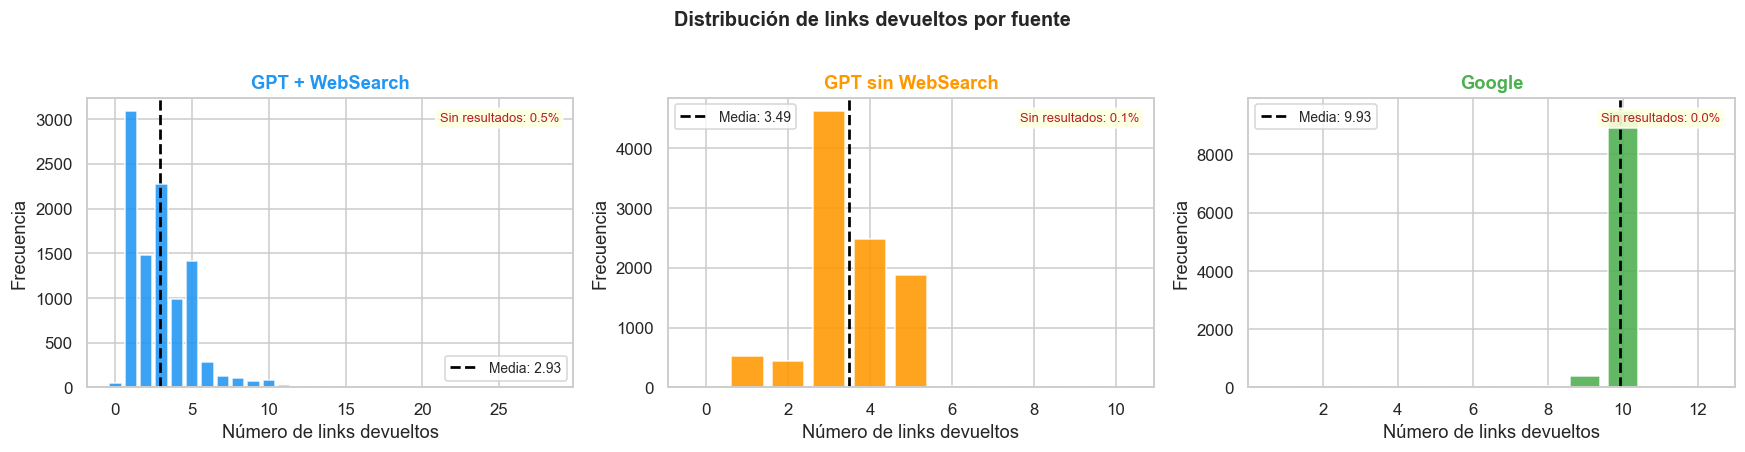

,Media,Mediana,Std,Min,Max,% sin resultados
Fuente,,,,,,
GPT + WebSearch,2.93,3.0,1.97,0,28,0.5
GPT sin WebSearch,3.49,3.0,1.05,0,10,0.1
Google,9.93,10.0,0.38,1,12,0.0


In [3]:
sources = [
    ('n_gpt_search',   'GPT + WebSearch',   COLORS['gpt_search']),
    ('n_gpt_nosearch', 'GPT sin WebSearch', COLORS['gpt_nosearch']),
    ('n_google',       'Google',            COLORS['google']),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (col, label, color) in zip(axes, sources):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=color, edgecolor='white', alpha=0.88)
    ax.axvline(df[col].mean(), color='black', linestyle='--', lw=1.8,
               label=f'Media: {df[col].mean():.2f}')
    ax.set_title(label, fontweight='bold', color=color)
    ax.set_xlabel('Número de links devueltos')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
    pct0 = (df[col] == 0).mean() * 100
    ax.text(0.97, 0.95, f'Sin resultados: {pct0:.1f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
            color='firebrick',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

plt.suptitle('Distribución de links devueltos por fuente', y=1.02,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen
rows = []
for col, label, _ in sources:
    s = df[col]
    rows.append({'Fuente': label, 'Media': round(s.mean(),2),
                 'Mediana': s.median(), 'Std': round(s.std(),2),
                 'Min': s.min(), 'Max': s.max(),
                 '% sin resultados': round((s==0).mean()*100, 1)})
pd.DataFrame(rows).set_index('Fuente')

In [4]:
for ax, (col, label, color) in zip(axes, sources):
    vc = df[col].value_counts().sort_index()
    print(f"\n--- {label} ---")
    print(vc)


--- GPT + WebSearch ---
n_gpt_search
0       46
1     3086
2     1480
3     2271
4      988
5     1417
6      285
7      132
8      106
9       66
10      80
11      22
12      11
13       1
14       3
15       2
17       2
20       1
28       1
Name: count, dtype: int64

--- GPT sin WebSearch ---
n_gpt_nosearch
0       13
1      518
2      443
3     4617
4     2487
5     1883
6       24
7        5
8        4
9        2
10       4
Name: count, dtype: int64

--- Google ---
n_google
1        1
2        1
3        3
4        1
5        2
6       12
7       30
8       53
9      406
10    9478
11      12
12       1
Name: count, dtype: int64


---
## 3. Similitud global entre los 3 pares de fuentes

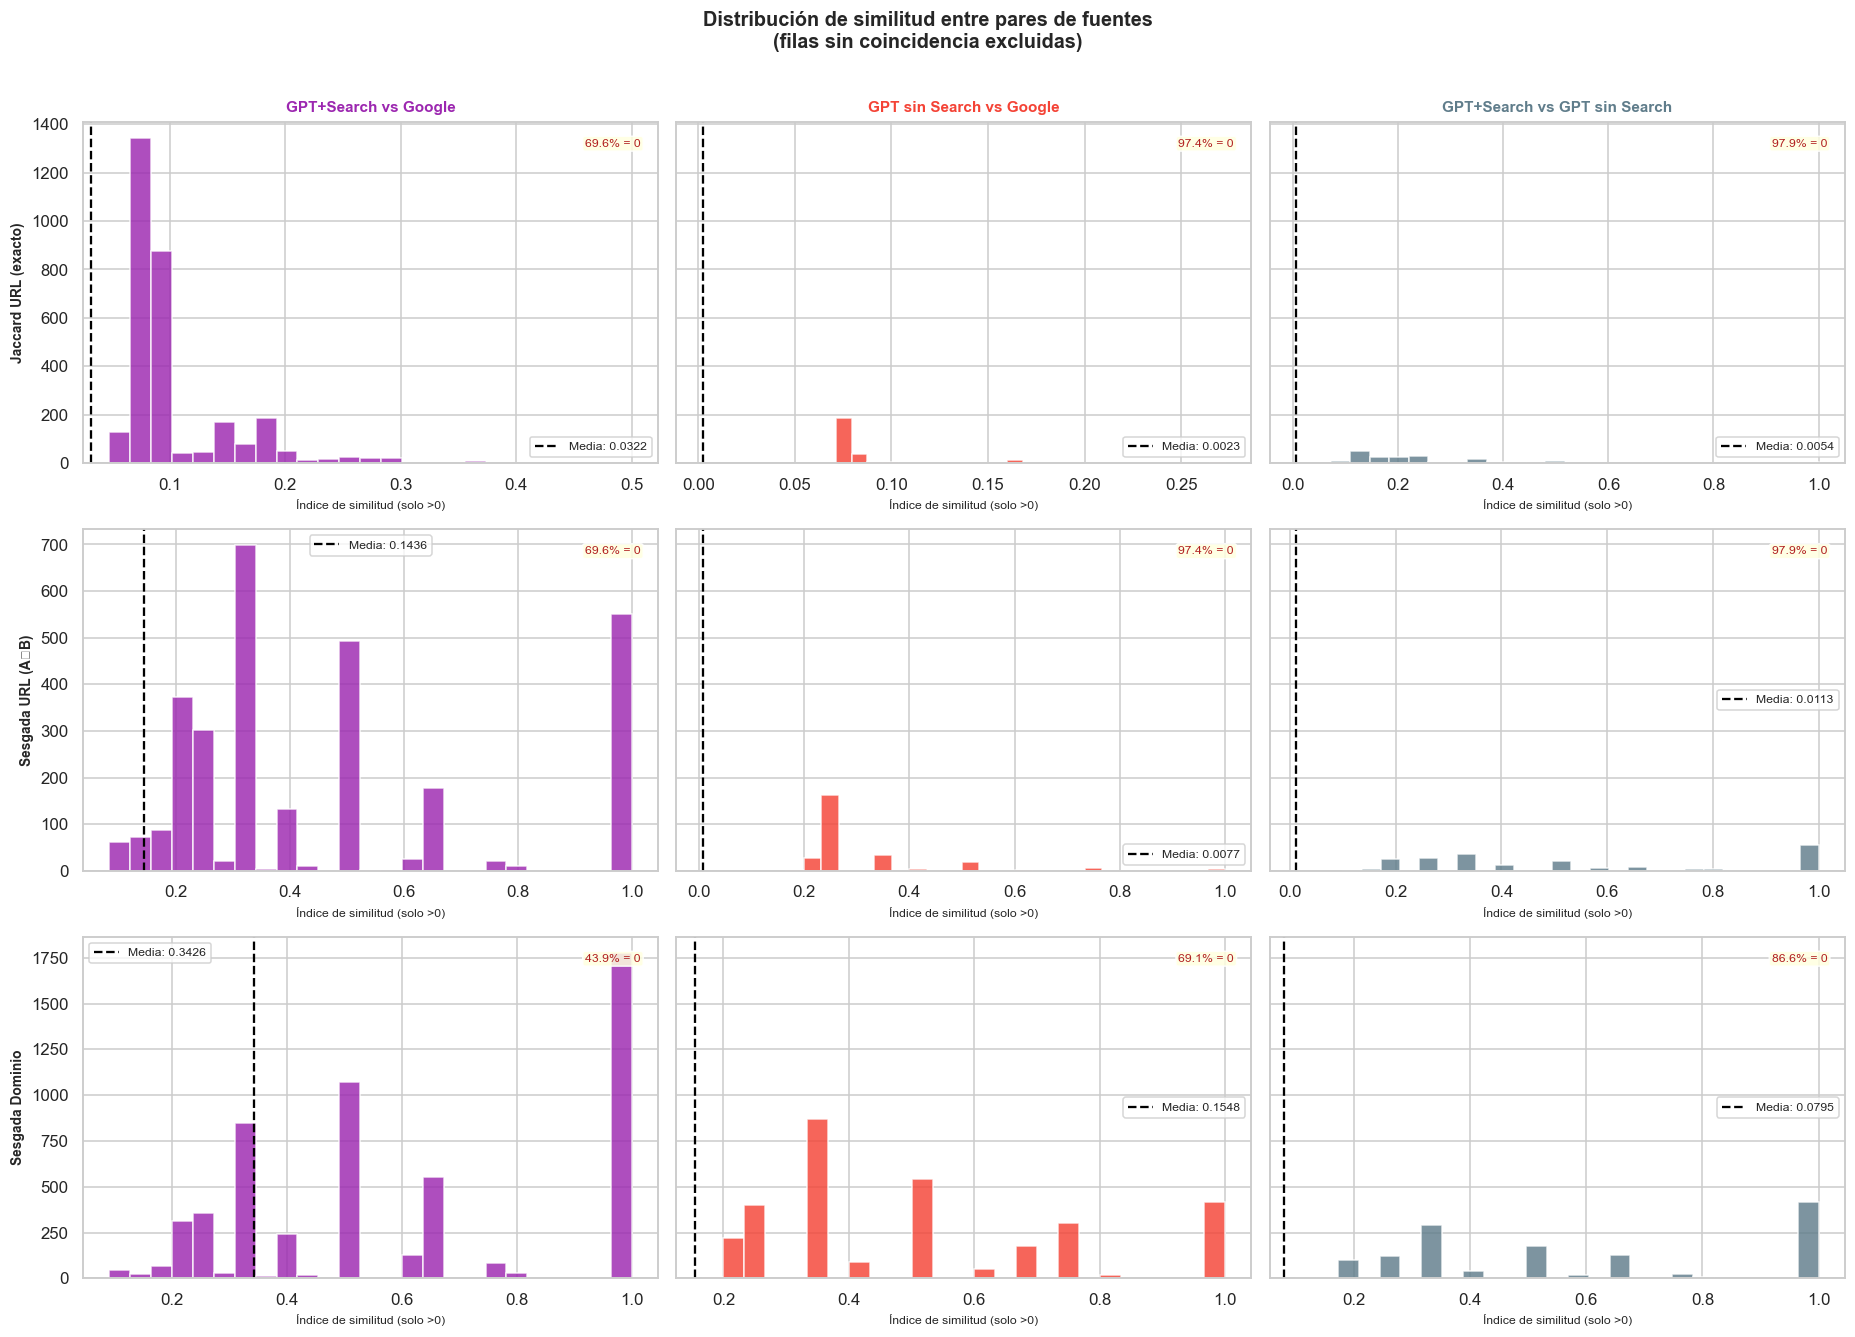

In [6]:
pair_colors = ['#9C27B0', '#F44336', '#607D8B']
metrics = ['jac', 'sg_url', 'sg_dom']
metric_labels = ['Jaccard URL (exacto)', 'Sesgada URL (A⊆B)', 'Sesgada Dominio']

fig, axes = plt.subplots(3, 3, figsize=(17, 12), sharey='row')

for col_i, (a, b, pair_label) in enumerate(PAIRS):
    key = f'{a}__{b}'
    color = pair_colors[col_i]
    for row_i, (metric, mlabel) in enumerate(zip(metrics, metric_labels)):
        ax = axes[row_i][col_i]
        s = df[f'{metric}_{key}']
        s_pos = s[s > 0]
        ax.hist(s_pos, bins=25, color=color, alpha=0.82, edgecolor='white')
        ax.axvline(s.mean(), color='black', linestyle='--', lw=1.5,
                   label=f'Media: {s.mean():.4f}')
        pct0 = (s == 0).mean() * 100
        ax.text(0.97, 0.95, f'{pct0:.1f}% = 0', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color='firebrick',
                bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.85))
        if row_i == 0:
            ax.set_title(pair_label, fontweight='bold', color=color, fontsize=10)
        if col_i == 0:
            ax.set_ylabel(mlabel, fontweight='bold', fontsize=9)
        ax.set_xlabel('Índice de similitud (solo >0)', fontsize=8)
        ax.legend(fontsize=8)

plt.suptitle('Distribución de similitud entre pares de fuentes\n(filas sin coincidencia excluidas)',
             y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Tabla comparativa resumen
rows = []
for a, b, label in PAIRS:
    key = f'{a}__{b}'
    rows.append({
        'Par': label,
        'Jaccard URL (media)':   round(df[f'jac_{key}'].mean(), 4),
        '% sin coincid. URL':    round((df[f'jac_{key}']==0).mean()*100, 1),
        'Sesgada URL (media)':   round(df[f'sg_url_{key}'].mean(), 4),
        'Sesgada Dom. (media)':  round(df[f'sg_dom_{key}'].mean(), 4),
        '% sin coincid. Dom.':   round((df[f'sg_dom_{key}']==0).mean()*100, 1),
    })
pd.DataFrame(rows).set_index('Par')

,Jaccard URL (media),% sin coincid. URL,Sesgada URL (media),Sesgada Dom. (media),% sin coincid. Dom.
Par,,,,,
GPT+Search vs Google,0.0322,69.6,0.1436,0.3426,43.8
GPT sin Search vs Google,0.0023,97.4,0.0077,0.1548,69.1
GPT+Search vs GPT sin Search,0.0054,97.9,0.0113,0.0795,86.6


---
## 4. Gráfico de barras comparativo: similitud por par y métrica

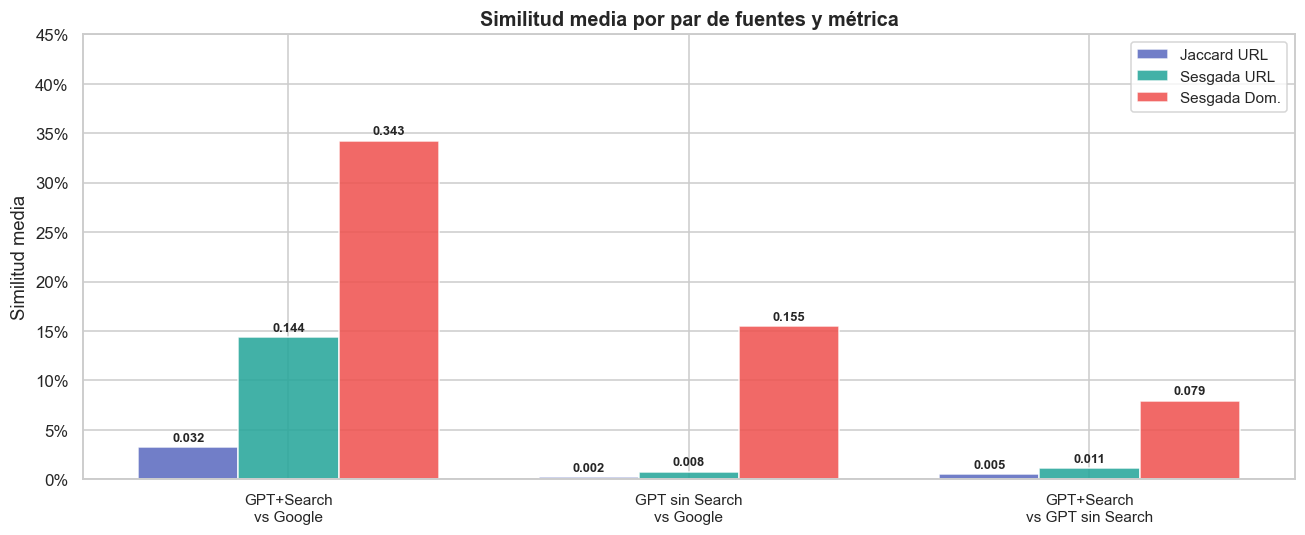

In [8]:
pair_labels_short = ['GPT+Search\nvs Google', 'GPT sin Search\nvs Google', 'GPT+Search\nvs GPT sin Search']
metric_cols   = ['jac', 'sg_url', 'sg_dom']
metric_names  = ['Jaccard URL', 'Sesgada URL', 'Sesgada Dom.']
bar_colors    = ['#5C6BC0', '#26A69A', '#EF5350']

x = np.arange(len(PAIRS))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

for i, (mcol, mname, bcolor) in enumerate(zip(metric_cols, metric_names, bar_colors)):
    vals = [df[f'{mcol}_{a}__{b}'].mean() for a, b, _ in PAIRS]
    bars = ax.bar(x + i*width, vals, width, label=mname, color=bcolor, alpha=0.87, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(pair_labels_short, fontsize=10)
ax.set_ylabel('Similitud media')
ax.set_title('Similitud media por par de fuentes y métrica', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 0.45)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

---
## 5. Similitud de dominio por categoría — comparativa de los 3 pares

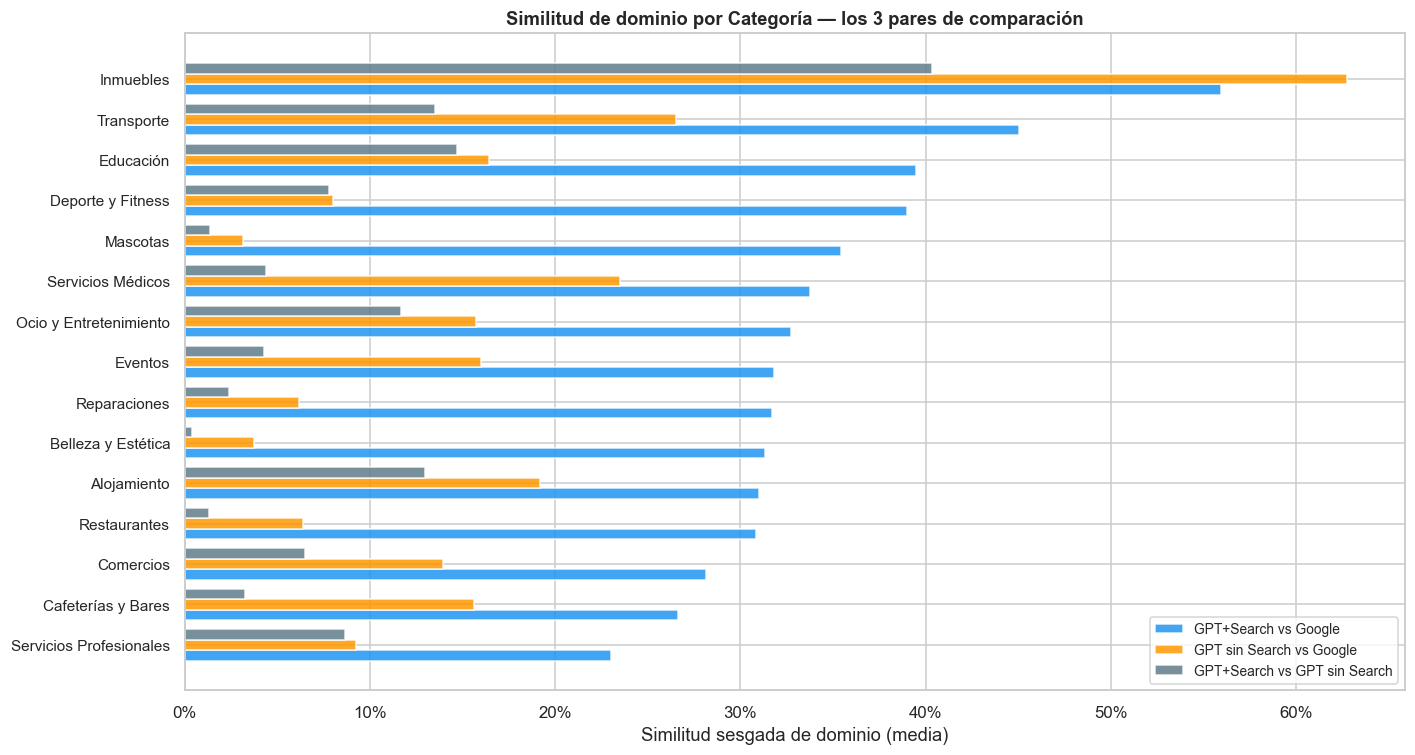

In [9]:
cat_order = df.groupby('Categoría')['sg_dom_gpt_search__google'].mean().sort_values().index

cat_means = {}
for a, b, label in PAIRS:
    key = f'{a}__{b}'
    cat_means[label] = df.groupby('Categoría')[f'sg_dom_{key}'].mean()

fig, ax = plt.subplots(figsize=(13, 7))

x = np.arange(len(cat_order))
w = 0.26
pcolors = ['#2196F3', '#FF9800', '#607D8B']

for i, ((_, _, label), color) in enumerate(zip(PAIRS, pcolors)):
    vals = [cat_means[label][cat] for cat in cat_order]
    ax.barh(x + i*w, vals, w, label=label, color=color, alpha=0.85, edgecolor='white')

ax.set_yticks(x + w)
ax.set_yticklabels(cat_order, fontsize=10)
ax.set_xlabel('Similitud sesgada de dominio (media)')
ax.set_title('Similitud de dominio por Categoría — los 3 pares de comparación',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

---
## 6. Heatmap: similitud de dominio por categoría y par

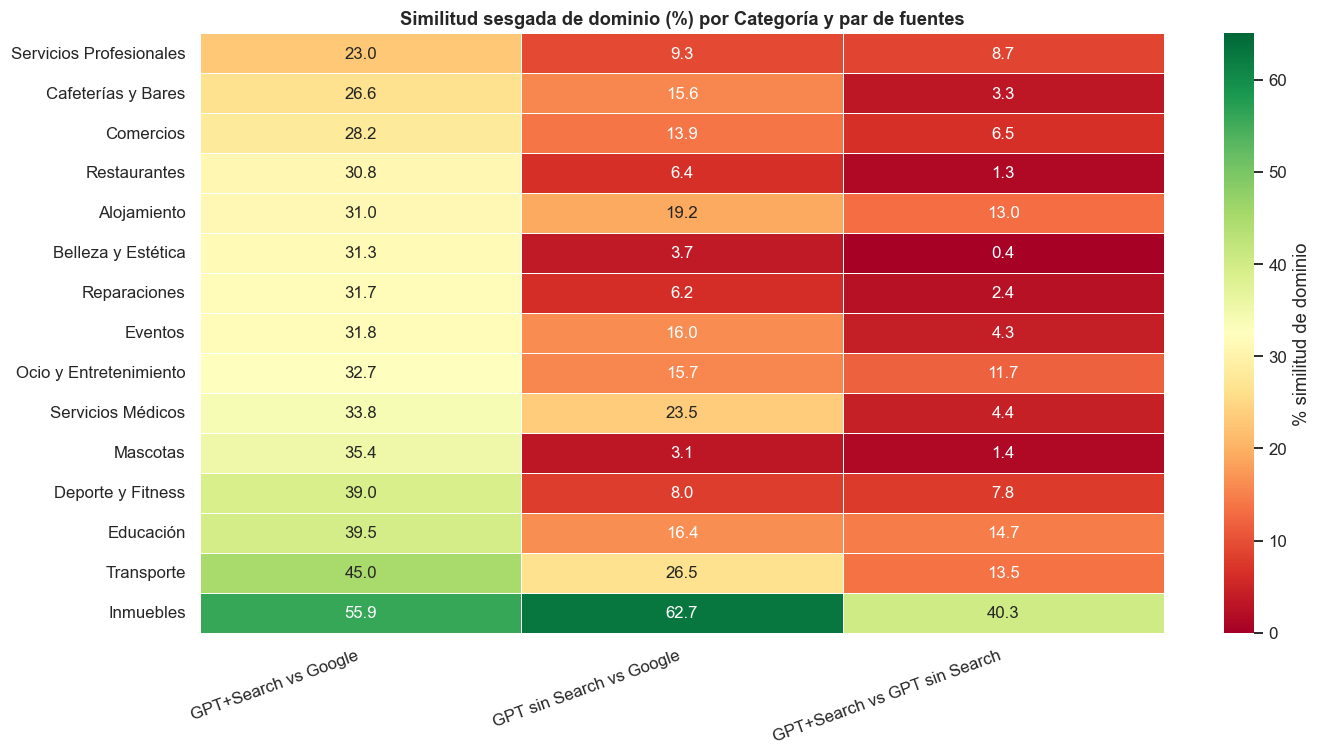

In [10]:
hm_data = pd.DataFrame({
    'GPT+Search vs Google':          df.groupby('Categoría')['sg_dom_gpt_search__google'].mean(),
    'GPT sin Search vs Google':      df.groupby('Categoría')['sg_dom_gpt_nosearch__google'].mean(),
    'GPT+Search vs GPT sin Search':  df.groupby('Categoría')['sg_dom_gpt_search__gpt_nosearch'].mean(),
}).sort_values('GPT+Search vs Google')

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(hm_data * 100, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=65,
            cbar_kws={'label': '% similitud de dominio'})
ax.set_title('Similitud sesgada de dominio (%) por Categoría y par de fuentes',
             fontweight='bold', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

---
## 7. Top dominios por fuente — comparativa

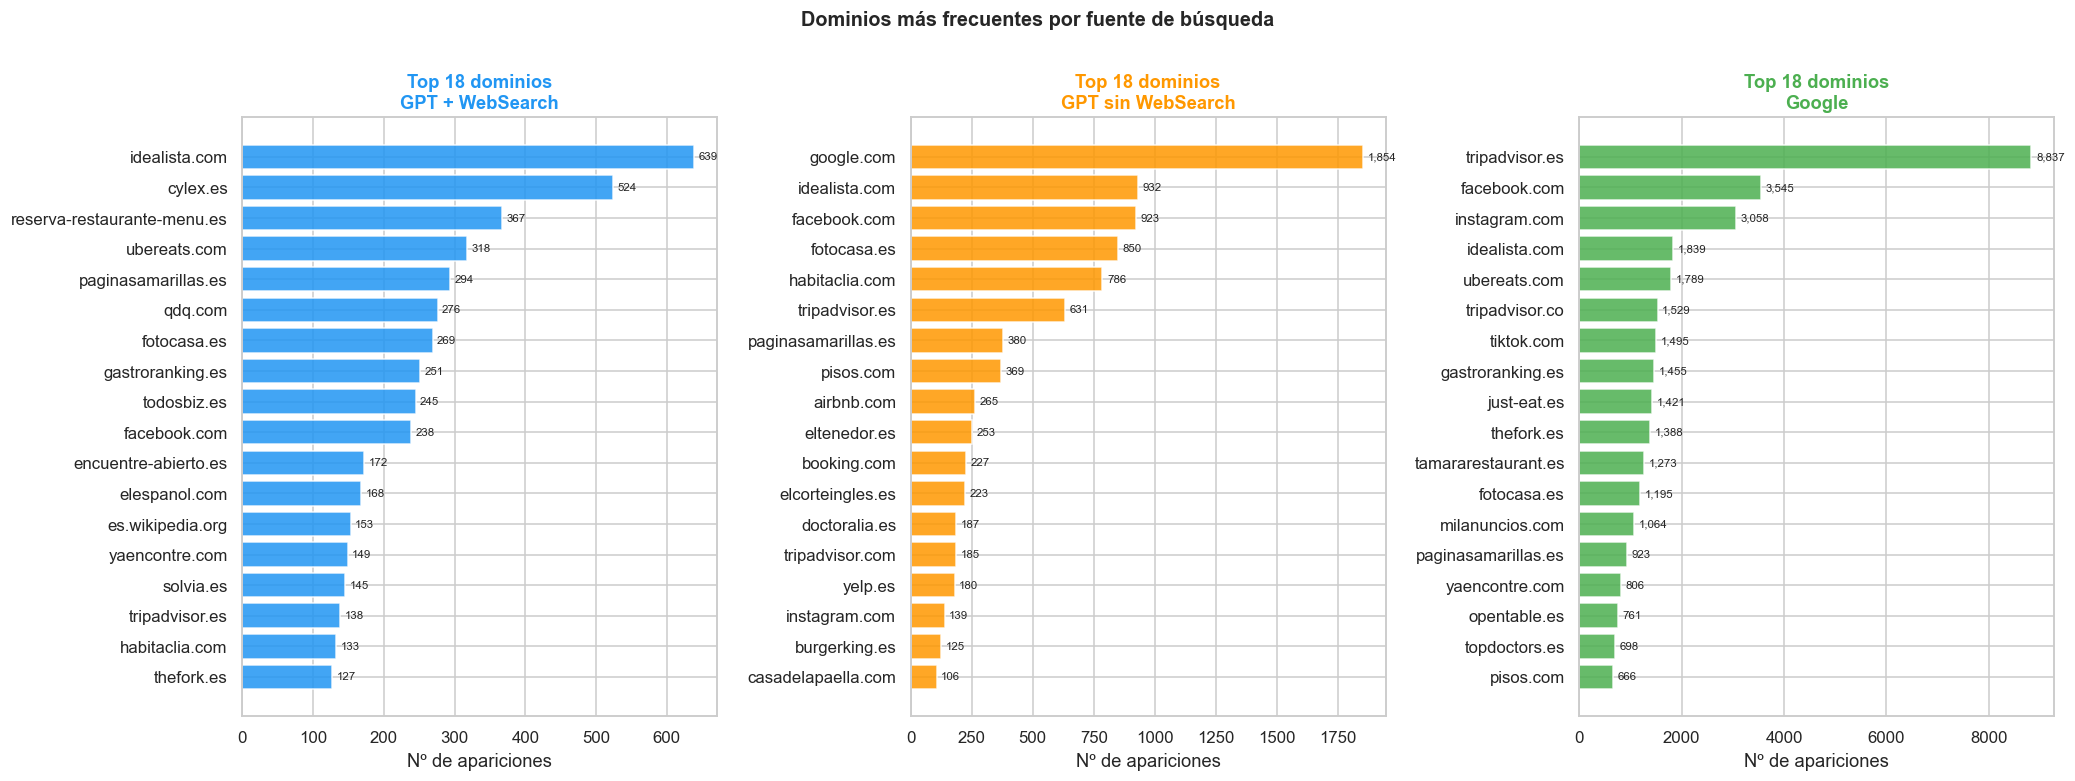

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))

sources_dom = [
    ('dom_gpt_search',   'GPT + WebSearch',   COLORS['gpt_search']),
    ('dom_gpt_nosearch', 'GPT sin WebSearch', COLORS['gpt_nosearch']),
    ('dom_google',       'Google',            COLORS['google']),
]

for ax, (col, label, color) in zip(axes, sources_dom):
    all_d = [d for lst in df[col] for d in lst]
    top = Counter(all_d).most_common(18)
    domains = [d for d, _ in top][::-1]
    counts  = [c for _, c in top][::-1]
    bars = ax.barh(domains, counts, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Top 18 dominios\n{label}', fontweight='bold', color=color)
    ax.set_xlabel('Nº de apariciones')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
                f'{int(w):,}', va='center', fontsize=7.5)

plt.suptitle('Dominios más frecuentes por fuente de búsqueda', y=1.01,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Universo de dominios: solapamientos entre las 3 fuentes

┌──────────────────────────────────────────────────────────────┐
│              UNIVERSO DE DOMINIOS ÚNICOS                    │
├──────────────────────────────────────────────────────────────┤
│  GPT + WebSearch:          12,508 dominios únicos           │
│  GPT sin WebSearch:        13,088 dominios únicos           │
│  Google:                   19,974 dominios únicos           │
├──────────────────────────────────────────────────────────────┤
│  Comunes a los 3:             334                          │
│  GPT+Search ∩ Google:       4,931 (39.4% de los de GPT+S)   │
│  GPT noSearch ∩ Google:       529 (4.0% de los de GPT-NS)  │
│  GPT+S ∩ GPT-NS:              666 (5.3% de los de GPT+S)   │
└──────────────────────────────────────────────────────────────┘


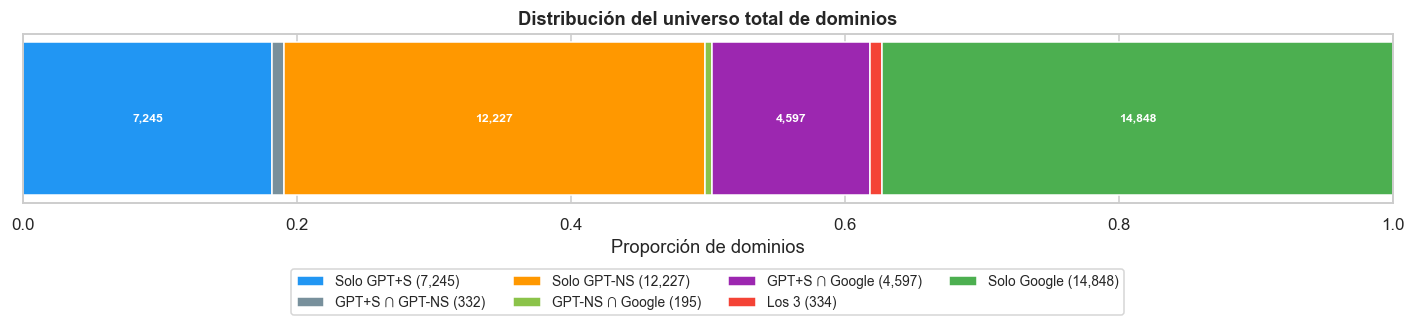

In [12]:
all_gpt_s  = [d for lst in df['dom_gpt_search']   for d in lst]
all_gpt_ns = [d for lst in df['dom_gpt_nosearch'] for d in lst]
all_goog   = [d for lst in df['dom_google']        for d in lst]

S  = set(all_gpt_s)
NS = set(all_gpt_ns)
G  = set(all_goog)

print('┌──────────────────────────────────────────────────────────────┐')
print('│              UNIVERSO DE DOMINIOS ÚNICOS                    │')
print('├──────────────────────────────────────────────────────────────┤')
print(f'│  GPT + WebSearch:         {len(S):>7,} dominios únicos           │')
print(f'│  GPT sin WebSearch:       {len(NS):>7,} dominios únicos           │')
print(f'│  Google:                  {len(G):>7,} dominios únicos           │')
print('├──────────────────────────────────────────────────────────────┤')
print(f'│  Comunes a los 3:         {len(S & NS & G):>7,}                          │')
print(f'│  GPT+Search ∩ Google:     {len(S & G):>7,} ({len(S & G)/len(S)*100:.1f}% de los de GPT+S)   │')
print(f'│  GPT noSearch ∩ Google:   {len(NS & G):>7,} ({len(NS & G)/len(NS)*100:.1f}% de los de GPT-NS)  │')
print(f'│  GPT+S ∩ GPT-NS:          {len(S & NS):>7,} ({len(S & NS)/len(S)*100:.1f}% de los de GPT+S)   │')
print('└──────────────────────────────────────────────────────────────┘')

# Gráfico de bloques proporcional
fig, ax = plt.subplots(figsize=(13, 3.5))

only_s   = len(S - NS - G)
only_ns  = len(NS - S - G)
only_g   = len(G - S - NS)
s_ns     = len((S & NS) - G)
s_g      = len((S & G)  - NS)
ns_g     = len((NS & G) - S)
all3     = len(S & NS & G)

segments = [
    (only_s, '#2196F3', 'Solo GPT+S'),
    (s_ns,   '#78909C', 'GPT+S ∩ GPT-NS'),
    (only_ns,'#FF9800', 'Solo GPT-NS'),
    (ns_g,   '#8BC34A', 'GPT-NS ∩ Google'),
    (s_g,    '#9C27B0', 'GPT+S ∩ Google'),
    (all3,   '#F44336', 'Los 3'),
    (only_g, '#4CAF50', 'Solo Google'),
]
total = sum(c for c, *_ in segments)
left = 0
for count, color, label in segments:
    width = count / total
    ax.barh(0, width, left=left, color=color, edgecolor='white', height=0.5, label=f'{label} ({count:,})')
    if width > 0.03:
        ax.text(left + width/2, 0, f'{count:,}', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')
    left += width

ax.set_yticks([])
ax.set_xlim(0, 1)
ax.set_xlabel('Proporción de dominios')
ax.set_title('Distribución del universo total de dominios', fontweight='bold')
ax.legend(bbox_to_anchor=(0.5, -0.35), loc='upper center', ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

---
## 9. Dominios exclusivos de cada fuente (no compartidos con las otras dos)

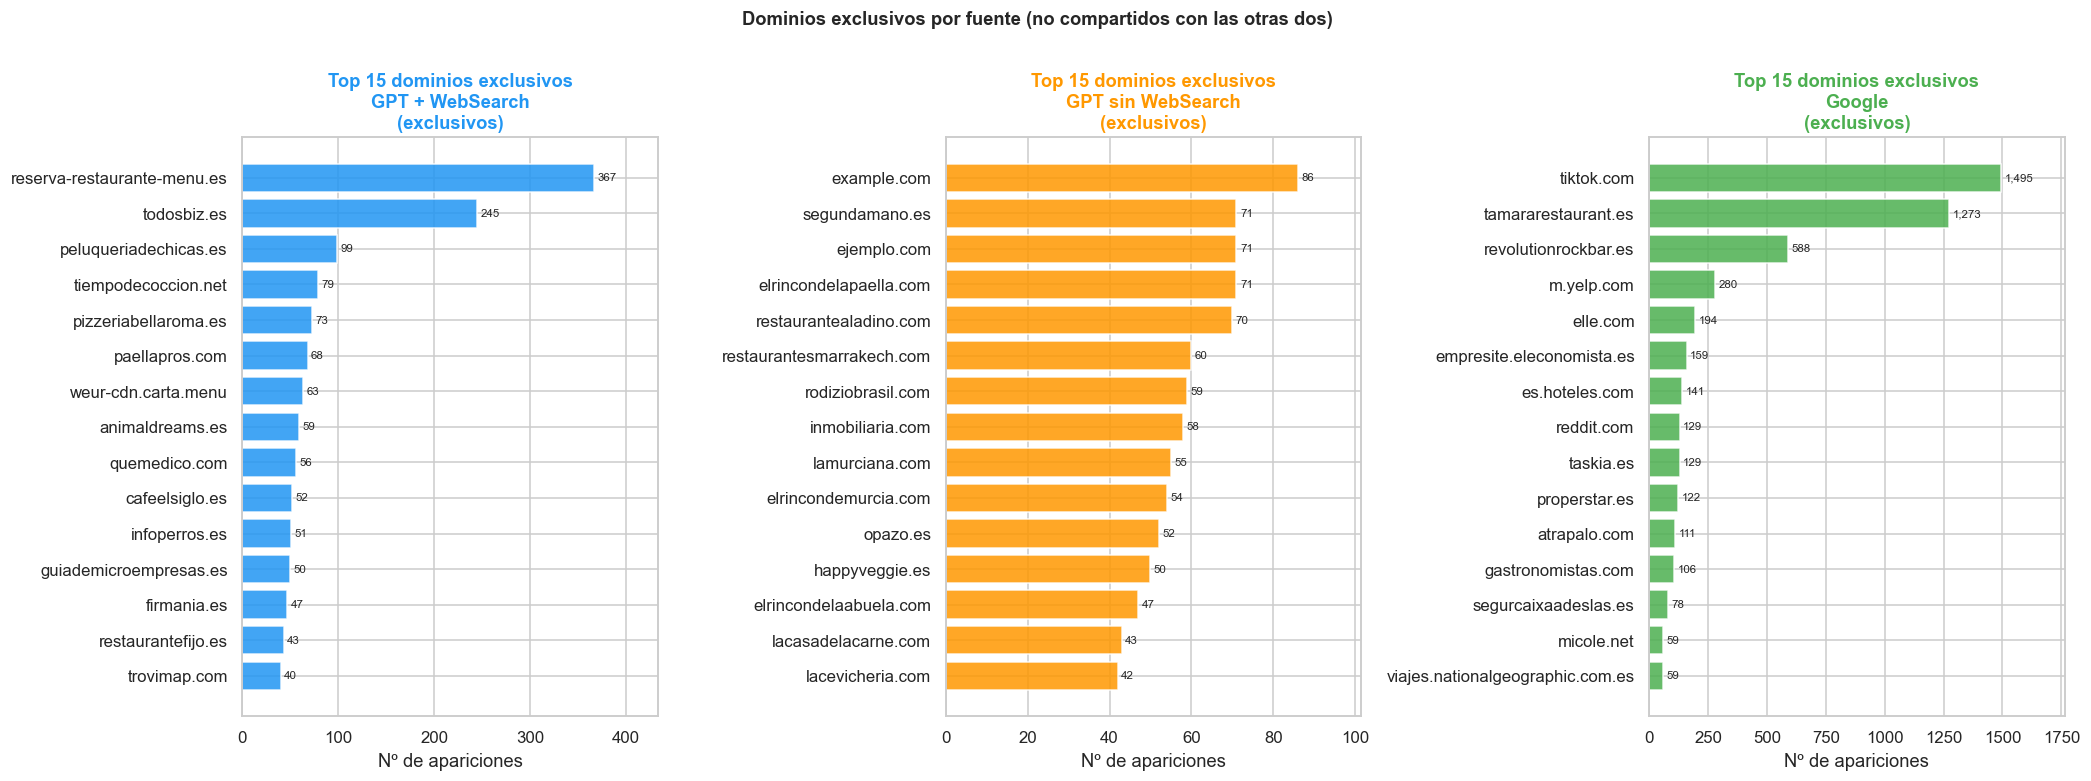

In [13]:
cnt_s  = Counter(all_gpt_s)
cnt_ns = Counter(all_gpt_ns)
cnt_g  = Counter(all_goog)

excl_s  = {d: c for d, c in cnt_s.items()  if d not in NS and d not in G}
excl_ns = {d: c for d, c in cnt_ns.items() if d not in S  and d not in G}
excl_g  = {d: c for d, c in cnt_g.items()  if d not in S  and d not in NS}

fig, axes = plt.subplots(1, 3, figsize=(19, 7))

for ax, excl_dict, label, color in [
    (axes[0], excl_s,  'GPT + WebSearch\n(exclusivos)', COLORS['gpt_search']),
    (axes[1], excl_ns, 'GPT sin WebSearch\n(exclusivos)', COLORS['gpt_nosearch']),
    (axes[2], excl_g,  'Google\n(exclusivos)', COLORS['google']),
]:
    top = Counter(excl_dict).most_common(15)
    domains = [d for d, _ in top][::-1]
    counts  = [c for _, c in top][::-1]
    ax.barh(domains, counts, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Top 15 dominios exclusivos\n{label}', fontweight='bold', color=color)
    ax.set_xlabel('Nº de apariciones')
    for i, (dom, cnt) in enumerate(zip(domains, counts)):
        ax.text(cnt + max(counts)*0.01, i, f'{cnt:,}', va='center', fontsize=7.5)
    ax.set_xlim(0, max(counts)*1.18)

plt.suptitle('Dominios exclusivos por fuente (no compartidos con las otras dos)',
             y=1.01, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. ¿Cómo varía la similitud cuando GPT sin search devuelve más links?

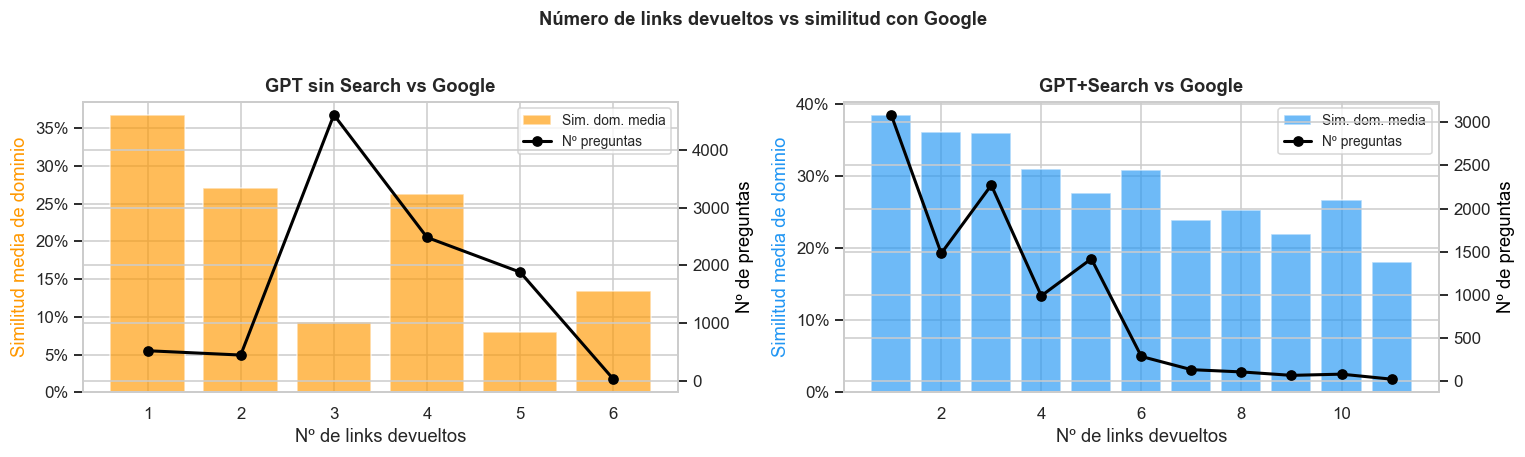

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (a, b, label), color in zip(axes,
    [PAIRS[1], PAIRS[0]],    # gpt_nosearch vs google primero
    [COLORS['gpt_nosearch'], COLORS['gpt_search']]):

    key = f'{a}__{b}'
    pivot = df[df[f'n_{a}'] > 0].groupby(f'n_{a}')[f'sg_dom_{key}'].agg(['mean','count'])
    pivot = pivot[pivot['count'] >= 15]

    ax2 = ax.twinx()
    ax.bar(pivot.index, pivot['mean'], color=color, alpha=0.65, label='Sim. dom. media')
    ax2.plot(pivot.index, pivot['count'], color='black', marker='o', lw=2, label='Nº preguntas')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Nº de links devueltos')
    ax.set_ylabel('Similitud media de dominio', color=color)
    ax2.set_ylabel('Nº de preguntas', color='black')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=9)

plt.suptitle('Número de links devueltos vs similitud con Google', y=1.03,
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## 11. Distribución en tramos — las 3 comparativas

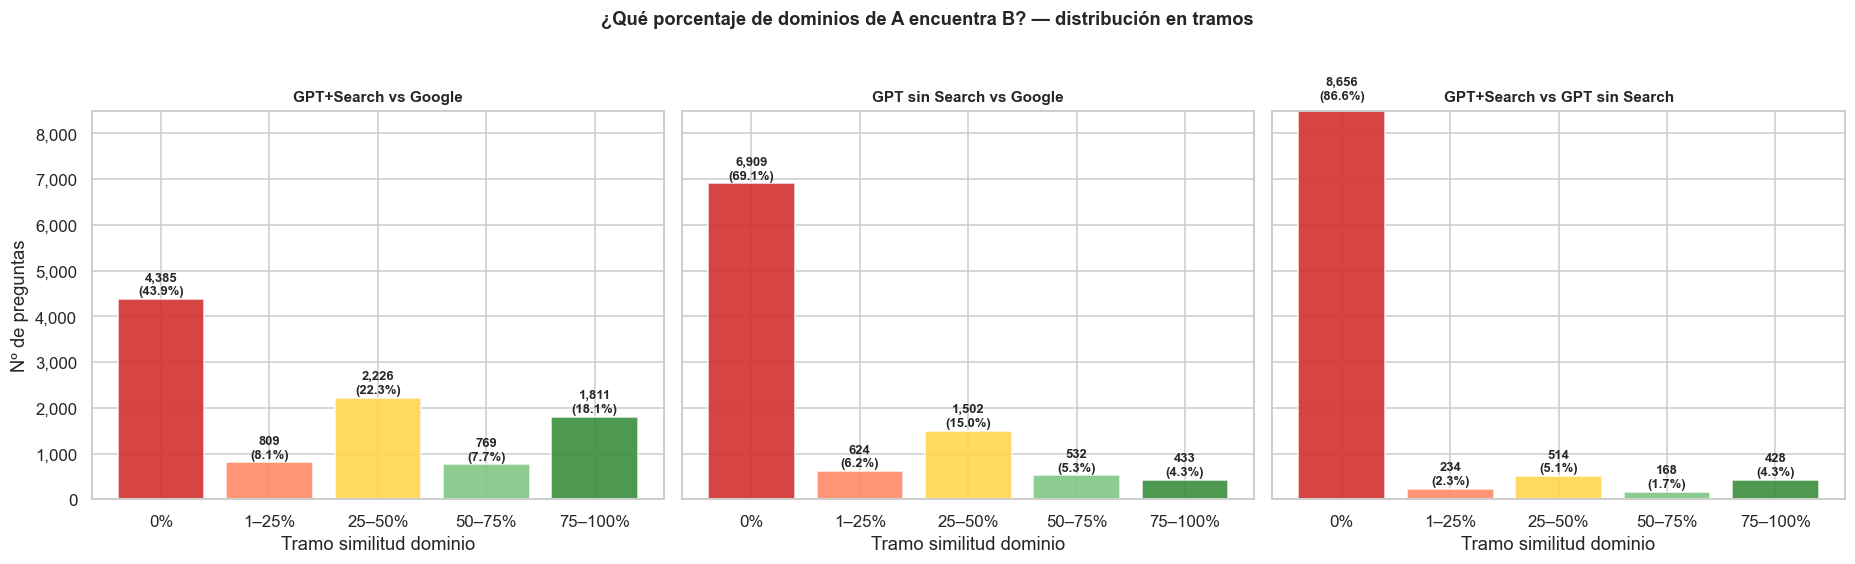

In [15]:
tramo_bins   = [-0.001, 0, 0.25, 0.5, 0.75, 1.001]
tramo_labels = ['0%', '1–25%', '25–50%', '50–75%', '75–100%']
tramo_colors = ['#D32F2F', '#FF8A65', '#FFD54F', '#81C784', '#388E3C']

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, (a, b, label) in zip(axes, PAIRS):
    key = f'{a}__{b}'
    tramos = pd.cut(df[f'sg_dom_{key}'], bins=tramo_bins, labels=tramo_labels)
    counts = tramos.value_counts().sort_index()
    bars = ax.bar(tramo_labels, [counts.get(t, 0) for t in tramo_labels],
                  color=tramo_colors, edgecolor='white', alpha=0.9)
    for bar in bars:
        h = bar.get_height()
        pct = h / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, h + 30,
                f'{h:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Tramo similitud dominio')
    if ax is axes[0]:
        ax.set_ylabel('Nº de preguntas')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_ylim(0, 8500)

plt.suptitle('¿Qué porcentaje de dominios de A encuentra B? — distribución en tramos',
             y=1.02, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Casos ejemplares: alta y baja coincidencia por par

In [16]:
pd.set_option('display.max_colwidth', 75)
cols_base = ['Categoría','Subcategoría','Pregunta_Reformulada']

for a, b, label in PAIRS:
    key = f'{a}__{b}'
    col_sim = f'sg_dom_{key}'
    print('═'*80)
    print(f'PAR: {label}')
    print('── Top 4 con MAYOR coincidencia de dominio ──')
    mask_has = df[f'n_{a}'] > 0
    top4 = df[mask_has].nlargest(4, col_sim)[cols_base + [col_sim, f'dom_{a}', f'dom_{b}']]
    display(top4)
    print('── 4 casos con 0% coincidencia (A tenía links) ──')
    mask0 = (df[col_sim] == 0) & (df[f'n_{a}'] > 0)
    display(df[mask0].sample(4, random_state=7)[cols_base + [col_sim, f'dom_{a}', f'dom_{b}']])
    print()

════════════════════════════════════════════════════════════════════════════════
PAR: GPT+Search vs Google
── Top 4 con MAYOR coincidencia de dominio ──


,Categoría,Subcategoría,Pregunta_Reformulada,sg_dom_gpt_search__google,dom_gpt_search,dom_google
9,Restaurantes,Sushi - Alicante,¿Dónde puedo encontrar un buen restaurante de sushi en Alicante?,1.0,[misssushi.es],"[thefork.es, tripadvisor.es, opentable.es, abc.es, tripadvisor.es, sush..."
14,Deporte y Fitness,Gimnasios - L'Hospitalet de Llobregat,¿Cuáles son los mejores gimnasios en L'Hospitalet de Llobregat?,1.0,[gimnasiosbarcelona.com],"[gimnasiosbarcelona.com, basic-fit.com, vivagym.com, gimnasios.com, clu..."
40,Restaurantes,Paquistaní - Albacete,¿Cuál es el mejor restaurante paquistaní en Albacete?,1.0,[ubereats.com],"[tripadvisor.es, thefork.es, ubereats.com, tiktok.com, instagram.com, m..."
43,Restaurantes,Coreana - San Sebastián,¿Cuál es el mejor restaurante de comida coreana en San Sebastián?,1.0,"[noticiasdegipuzkoa.eus, bstar-restaurant.com]","[tripadvisor.es, noticiasdegipuzkoa.eus, thefork.es, bstar-restaurant.c..."


── 4 casos con 0% coincidencia (A tenía links) ──


,Categoría,Subcategoría,Pregunta_Reformulada,sg_dom_gpt_search__google,dom_gpt_search,dom_google
4014,Servicios Profesionales,Peritos - Zaragoza,¿Dónde puedo encontrar peritos en Zaragoza?,0.0,"[peritoszaragoza.com, peritosjudicialeszaragoza.com, peritoszaragoza.org]","[gp-grup.com, aspejure.com, peritajesinvestiga.es, horizonperitos.com, ..."
4430,Restaurantes,Cocina De Autor - Madrid,¿Cuáles son los mejores restaurantes de cocina de autor en Madrid?,0.0,"[diverxo.com, elcluballard.com, atico-madrid.com, ramses.life, latasque...","[guide.michelin.com, conelmorrofino.com, thefork.es, telecinco.es, elmu..."
1832,Comercios,Panaderías - Burgos,¿Dónde puedo encontrar panaderías en Burgos?,0.0,"[qdq.com, tartapan.com, panaderiasartesanas.com, panaderiasartesanas.co...","[tripadvisor.es, tripadvisor.es, wanderlog.com, elhorno.net, panaderial..."
8798,Restaurantes,Gallega - Soria,¿Dónde puedo encontrar un restaurante de comida gallega en Soria?,0.0,[elreceton.com],"[tripadvisor.es, facebook.com, paradores.es, tripadvisor.es, qdq.com, i..."



════════════════════════════════════════════════════════════════════════════════
PAR: GPT sin Search vs Google
── Top 4 con MAYOR coincidencia de dominio ──


...

,Categoría,Subcategoría,Pregunta_Reformulada,sg_dom_gpt_nosearch__google,dom_gpt_nosearch,dom_google
7437,Restaurantes,Fusión - San Sebastián,¿Cuál es el mejor restaurante de comida fusión en San Sebastián?,0.0,"[mugaritz.com, karlosarguinano.com, zuberoa.com]","[tripadvisor.es, thefork.es, opentable.es, sistersandthecity.com, notic..."
4600,Comercios,Tienda De Conveniencia - Sevilla,¿Dónde puedo encontrar una tienda de conveniencia en Sevilla?,0.0,"[google.com, 7-eleven.com, carrefour.es]","[empresite.eleconomista.es, metro24st.com, paginasamarillas.es, masandg..."
3159,Restaurantes,Fusión - Tarragona,¿Dónde puedo encontrar un restaurante de fusión en Tarragona?,0.0,"[lacuinadelceller.com, elllagut.com, laxarxa.com]","[tripadvisor.es, tripadvisor.es, gastroranking.es, eltallertgn.com, elc..."
8231,Restaurantes,Pasta Italiana - Bilbao,¿Cuál es el mejor restaurante de pasta italiana en Bilbao?,0.0,"[bistrodelaria.com, lapasta.com, donvito.com]","[tripadvisor.es, tripadvisor.es, deia.eus, ilgiardinodellanonna.es, lat..."



════════════════════════════════════════════════════════════════════════════════
PAR: GPT+Search vs GPT sin Search
── Top 4 con MAYOR coincidencia de dominio ──


,Categoría,Subcategoría,Pregunta_Reformulada,sg_dom_gpt_search__gpt_nosearch,dom_gpt_search,dom_gpt_nosearch
63,Inmuebles,Dúplex - Tenerife,¿Dónde puedo comprar un dúplex en Tenerife?,1.0,[idealista.com],"[idealista.com, fotocasa.es, habitaclia.com, inmobiliariatenerife.com]"
76,Inmuebles,Dúplex - Vigo,¿Dónde puedo alquilar un dúplex en Vigo?,1.0,[idealista.com],"[idealista.com, fotocasa.es, habitaclia.com, pisos.com]"
83,Deporte y Fitness,Ciclismo - San Sebastián,¿Dónde puedo practicar ciclismo en San Sebastián?,1.0,"[sansebastianturismo.com, sansebastianturismo.com, sansebastianturismo....","[sansebastianturismo.com, sansebastianturismo.com, caminodesantiago.gal..."
85,Comercios,Supermercados - Burgos,¿Cuáles son los horarios de los supermercados en Burgos?,1.0,[mercadona.es],"[mercadona.es, carrefour.es, lidl.es, alcampo.es]"


── 4 casos con 0% coincidencia (A tenía links) ──


,Categoría,Subcategoría,Pregunta_Reformulada,sg_dom_gpt_search__gpt_nosearch,dom_gpt_search,dom_gpt_nosearch
1326,Inmuebles,Terrenos - Toledo,¿Dónde puedo alquilar terrenos en Toledo?,0.0,"[toledo.terrenos.es, yaencontre.com]","[idealista.com, fotocasa.es, habitaclia.com, milanuncios.com]"
4097,Eventos,Decoradores - Las Palmas,¿Dónde puedo encontrar decoradores en Las Palmas?,0.0,"[planreforma.com, decoradorlaspalmas.com, linodecoracion.es]",[paginasamarillas.es]
2290,Restaurantes,Peruana - Gran Canaria,¿Cuál es el mejor restaurante peruano en Gran Canaria?,0.0,"[novacircle.com, novacircle.com]","[eltallergrancanaria.com, lacevicheria.com, piscograncanaria.com]"
6198,Restaurantes,Catalana - Lleida,¿Dónde puedo encontrar un restaurante de comida catalana en Lleida?,0.0,"[macarfi.com, macarfi.com, macarfi.com, macarfi.com, macarfi.com, elcon...","[lafondalleida.com, elcellerdelavi.com, calxico.com]"


---
## 13. Resumen Ejecutivo: tabla final de las 3 fuentes

In [17]:
# Tabla completa de stats
rows = []
for a, b, label in PAIRS:
    key = f'{a}__{b}'
    rows.append({
        'Comparación': label,
        'Jaccard URL': df[f'jac_{key}'].mean(),
        '% 0-coincid. URL': (df[f'jac_{key}']==0).mean()*100,
        'Sesgada URL (A→B)': df[f'sg_url_{key}'].mean(),
        'Sesgada Dom. (A→B)': df[f'sg_dom_{key}'].mean(),
        '% 0-coincid. Dom.': (df[f'sg_dom_{key}']==0).mean()*100,
    })
resumen_df = pd.DataFrame(rows).set_index('Comparación').round(3)
resumen_df.style.background_gradient(cmap='RdYlGn', subset=['Jaccard URL','Sesgada URL (A→B)','Sesgada Dom. (A→B)']) \
                .background_gradient(cmap='RdYlGn_r', subset=['% 0-coincid. URL','% 0-coincid. Dom.'])

,Jaccard URL,% 0-coincid. URL,Sesgada URL (A→B),Sesgada Dom. (A→B),% 0-coincid. Dom.
Comparación,,,,,
GPT+Search vs Google,0.032000,69.560000,0.144000,0.343000,43.850000
GPT sin Search vs Google,0.002000,97.420000,0.008000,0.155000,69.090000
GPT+Search vs GPT sin Search,0.005000,97.940000,0.011000,0.079000,86.560000


In [18]:
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║        CONCLUSIONES CLAVE — 3 FUENTES DE BÚSQUEDA LOCAL                 ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  1. CANTIDAD DE RESULTADOS                                               ║
║     • Google: ~10 links/query (muy consistente)                          ║
║     • GPT sin search: ~3.5 links/query (más estable que con search)      ║
║     • GPT con search: ~2.9 links/query (más selectivo, más variable)     ║
║                                                                          ║
║  2. COINCIDENCIA CON GOOGLE                                              ║
║     • GPT + WebSearch: 34.3% de dominios coinciden con Google            ║
║     • GPT sin WebSearch: solo 15.5% de dominios coinciden con Google     ║
║     → El websearch DUPLICA el alineamiento con Google                    ║
║                                                                          ║
║  3. COHERENCIA ENTRE LAS DOS VERSIONES DE GPT                            ║
║     • Solo el 8% de dominios de GPT+Search aparece en GPT sin Search     ║
║     → Los dos GPT son más diferentes entre sí que GPT+Search y Google   ║
║                                                                          ║
║  4. GPT SIN SEARCH: COMPORTAMIENTO CARACTERÍSTICO                        ║
║     • Recomienda google.com como recurso (1.854 veces)                   ║
║     • Domina con portales genéricos conocidos: idealista, facebook,      ║
║       fotocasa, habitaclia, tripadvisor (su "conocimiento estático")     ║
║     • Gran divergencia con Google real (97.4% de queries sin URL exacta) ║
║                                                                          ║
║  5. CATEGORÍAS DESTACADAS                                                ║
║     • Inmuebles: la más alineada en todos los pares (portales dominantes)║
║     • Belleza y Estética: GPT sin search casi no coincide (3.7%)         ║
║     • Mascotas/Restaurantes: GPT sin search muy desfasado del mercado    ║
║                                                                          ║
║  6. CONCLUSIÓN GLOBAL                                                    ║
║     GPT sin search conoce el "top of mind" de portales pero ignora       ║
║     los negocios locales reales. GPT+Search acerca mucho su respuesta   ║
║     a los resultados orgánicos de Google, aunque nunca los replica.      ║
║     Google permanece como la fuente más completa y actualizada.          ║
╚══════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════╗
║        CONCLUSIONES CLAVE — 3 FUENTES DE BÚSQUEDA LOCAL                 ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  1. CANTIDAD DE RESULTADOS                                               ║
║     • Google: ~10 links/query (muy consistente)                          ║
║     • GPT sin search: ~3.5 links/query (más estable que con search)      ║
║     • GPT con search: ~2.9 links/query (más selectivo, más variable)     ║
║                                                                          ║
║  2. COINCIDENCIA CON GOOGLE                                              ║
║     • GPT + WebSearch: 34.3% de dominios coinciden con Google            ║
║     • GPT sin WebSearch: solo 15.5% de dominios coinciden con Google     ║
║     → El websearch DUPLICA el alineamiento con Google                    ║